# Previsão de Intenção de Compra de Clientes em Loja Web

**Descrição do Projeto**

Neste projeto, o objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. A intenção é prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimora a experiência do cliente, como também permite que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, será usada uma base de dados que contém informações detalhadas sobre os clientes, incluindo:
- Dados demográficos (idade, renda, etc.)
- Informações sobre compras anteriores

**Base de dados**:
- Year_Birth: Ano de nascimento do cliente.
- Education: Nível de escolaridade do cliente.
- Marital_Status: Estado civil do cliente.
- Income: Renda anual da família do cliente.
- Kidhome: Número de crianças na casa do cliente.
- Recency: Número de dias desde a última compra do cliente.
- Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.
- MntWines: Valor gasto em vinhos nos últimos 2 anos.
- MntFruits: Valor gasto em frutas nos últimos 2 anos.
- MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.
- MntFishProducts: Valor gasto em peixes nos últimos 2 anos.
- MntSweetProducts: Valor gasto em doces nos últimos 2 anos.
- MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.
- NumDealsPurchases: Número de compras feitas com desconto
- NumStorePurchases: Número de compras feitas diretamente nas lojas.
- NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.
- Variável alvo:
    - **WebPurchases: Número de compras feitas pelo site da empresa.**

# Preparação dos Dados

## **Exploração e Limpeza:**

Analise e limpeza dos dados para a garantia de que estejam prontos para a modelagem.


**Configurações**

In [231]:
import pandas as pd
from sklearn.decomposition import PCA
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
# import numpy as np



In [89]:
df = pd.read_csv('marketing_campaign.csv', delimiter=';')
df.head(3)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1


**Correções de texto**

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

In [92]:
df.dtypes

Year_Birth             int64
Education             object
Marital_Status        object
Income               float64
Kidhome                int64
Recency                int64
MntWines               int64
MntFruits              int64
MntMeatProducts        int64
MntFishProducts        int64
MntSweetProducts       int64
MntGoldProds           int64
NumStorePurchases      int64
NumWebVisitsMonth      int64
Complain               int64
WebPurchases           int64
dtype: object

In [93]:
for i in df:
    if df[i].dtype == 'object':
        print(df[i].unique())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


O campo "Education" não apresenta nenhum valor desconhecido ou errado.  
O campo "Martial Status" apresenta dois valores desconhecidos, "Absurd" e "YOLO", além de alguns status incomuns como "Together", "Widow" e "Alone". Vamos ver o que eles representam na base:

In [94]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [95]:
print(f'O percentual que as categorias Absurd, YOLO e Alone representam é: {100*df['Marital_Status'].isin(['Absurd', 'YOLO', 'Alone']).sum()/df.index.size:.3f}%')
print(f'O percentual que a categoria Widow representa é: {100*df['Marital_Status'].isin(['Widow']).sum()/df.index.size:.3f}%')
print(f'O percentual que a categoria Together representa é: {100*df['Marital_Status'].isin(['Together']).sum()/df.index.size:.3f}%')

O percentual que as categorias Absurd, YOLO e Alone representam é: 0.312%
O percentual que a categoria Widow representa é: 3.438%
O percentual que a categoria Together representa é: 25.893%


Como as categorias Absurd, YOLO e Alone não representam uma quantidade razoável, optei por corrigí-las para "Single".

A categoria Togeher represente uma parcela significativa da amostra, indicando que uma grande quantidade de clientes se identificam com essa categoria, e não com Married. Isso pode significar um comportamento divergente entre as duas categorias.

Já o valor "Widow" representa uma amostra muito pequena da amostra. Manter a categoria pode acrescentar "ruído" a análise, enquanto a substituir pode omitir um comportamento de nicho. Optei por manter a categoria avaliar seu impacto ao longo da análise. 

In [96]:
for campo in ['Absurd', 'YOLO', 'Alone']:
     df.replace({'Marital_Status': campo}, 'Single', inplace=True)
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

### **Inspeção de possívei outliers**

O objetivo é avaliar se existem possíveis outlieres para guiar as decisões seguitens, ainda que eles possam não ser resolvidos nessa etapa.

In [97]:
df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,5.790179,5.316518,0.009375,0.503571
std,11.984069,25173.076661,0.538398,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,3.250958,2.426645,0.096391,0.500099
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,13.000000,20.000000,1.000000,1.000000


O valor máximo de income está alto,  O valor máximo de Income é muito maior do que 75%, mesmo que a variância seja somada a ele. Esse salto no valor deve ser investigado.

O valor max de todas as compras se destacam, mas ainda estão dentro do esperado para o intervalo de 2 anos. Os valores são razoáveis para um cliente frequente que compra produtos a dois anos na loja analisada, então não apresentam comportamento de outlier.

O valor mínimo do ano é anterior ao século passado, o que com certeza está errado.

Os demais valores apresentam comportamento dentro do esperado.

Na próxima etapa discutimos a presença de valores nulos em Income. Antes de corrigir esses números com os valores médios dessa variável, é preciso corrigir possíveis outliers.

In [98]:
campo = 'Income'
fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
fig.add_trace(
    px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
    row=1, col=1
    )
fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )
fig.update_layout(title_text=f'{campo}', showlegend=False)
fig.show()

A partir dos gráficos acima fica evidente que o atual valor máximo contém algum erro. Para simplificar e evitar a indução ao erro, o valor será excluído. Os demais valores que estão fora do boxplot não serão excluídos pois seu comportamento está de acordo com um comportamento padrão da distribuição desigual de renda. Segue abaixo a distribuição após a exclusão do valor máximo.

In [99]:
df = df[df['Income']!=df['Income'].max()].reset_index()
df.drop('index', axis=1, inplace=True)

In [100]:
campo = 'Income'
fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
fig.add_trace(
    px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
    row=1, col=1
    )
fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )
fig.update_layout(title_text=f'{campo}', showlegend=False)
fig.show()

**Ajuste do Ano de Nascimento**

Como mostramos gráficos abaixo, existem 3 valores (1900, 1899, 1893) que se destacam por serem impossíveis. Para corrigir esse erro, eles serão substituídos pelo valor mais baixo razoável, 1940.

O resultado final pode ser visto no segundo histograma e boxplot.

In [101]:
campo = 'Year_Birth'
fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
fig.add_trace(
    px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
    row=1, col=1
    )
fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )
fig.update_layout(title_text=f'{campo}', showlegend=False)
fig.show()

In [102]:
for ano in [1900, 1899, 1893]:
    df.replace({'Year_Birth': ano}, 1940, inplace=True)

In [103]:
campo = 'Year_Birth'
fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
fig.add_trace(
    px.histogram(df, x=campo, histnorm="percent", nbins=60).data[0],
    row=1, col=1
    )
fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )
fig.update_layout(title_text=f'{campo}', showlegend=False)
fig.show()

### Limpeza de valores nulos e faltantes

In [104]:
df.count()

Year_Birth           2239
Education            2239
Marital_Status       2239
Income               2215
Kidhome              2239
Recency              2239
MntWines             2239
MntFruits            2239
MntMeatProducts      2239
MntFishProducts      2239
MntSweetProducts     2239
MntGoldProds         2239
NumStorePurchases    2239
NumWebVisitsMonth    2239
Complain             2239
WebPurchases         2239
dtype: int64

In [105]:
df.isnull().sum()

Year_Birth            0
Education             0
Marital_Status        0
Income               24
Kidhome               0
Recency               0
MntWines              0
MntFruits             0
MntMeatProducts       0
MntFishProducts       0
MntSweetProducts      0
MntGoldProds          0
NumStorePurchases     0
NumWebVisitsMonth     0
Complain              0
WebPurchases          0
dtype: int64

In [106]:
df.sort_values('Income').tail(24)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
10,1983,Graduation,Married,NaN,1,11,5,5,6,0,2,1,2,7,0,0
27,1986,Graduation,Single,NaN,1,19,5,1,3,3,263,362,0,1,0,1
43,1959,PhD,Single,NaN,0,80,81,11,50,3,2,39,4,2,0,0
48,1951,Graduation,Single,NaN,2,96,48,5,48,6,10,7,4,6,0,0
58,1982,Graduation,Single,NaN,1,57,11,3,22,2,2,6,3,6,0,0
71,1973,2n Cycle,Married,NaN,1,25,25,3,43,17,4,17,3,8,0,0
90,1957,PhD,Married,NaN,2,4,230,42,192,49,37,53,8,9,0,1
91,1957,Graduation,Single,NaN,1,45,7,0,8,2,0,1,2,7,0,0
92,1973,Master,Together,NaN,0,87,445,37,359,98,28,18,8,1,0,0
128,1961,PhD,Married,NaN,0,23,352,0,27,10,0,15,7,6,0,1


Percentual que os nulos representam:

In [107]:
print(f'{100*df['Income'].isnull().sum()/df.index.size:.3f}%')

1.072%


Os valores nulos representam menos de 2% do total de dados, então podem ser excluídos sem grande perda. Contudo, com o objetivo de me desafiar e não perder dados, optei por substituí-los por outro valor. Ao invés de substituí-los pela média simples, eles foram substituídos pela média de Income para cada conjunto com o mesmo marital status e education.


O primeiro passo é registrar o valor dos índeces referentes aos valores nulos.

In [108]:
# Registro do index de cada valor nulo

index_geral=0
index_null = []
for i in df['Income'].isnull() :
    if i == True:
        index_null.append(index_geral)
    index_geral += 1
print(f'Os índices estão corretos se todos os valores de Income para os respectivos forem nulos e seu tamanho for 24:\nTamanho: {len(index_null)}\nSão nulos: {df['Income'].iloc[index_null].isnull().sum()}')

Os índices estão corretos se todos os valores de Income para os respectivos forem nulos e seu tamanho for 24:
Tamanho: 24
São nulos: 24


Para calcular a média para cada grupo, basta calcular a média agrupada. Dessa forma a variável irá guardar os valores médios de Income para cada par de valores em martial status e education.

In [109]:
# Cálculo da média por grupo
media_income_MS_Ed = df.groupby(['Marital_Status', 'Education'])['Income'].mean()
print(f'Por exemplo, para marital status = together e education = master, a é dia é: {media_income_MS_Ed['Together','Master']}')

Por exemplo, para marital status = together e education = master, a é dia é: 52109.009803921566


Agora, para cada índice registrado em index_null, o valor Nan de Income será substituído pela respectiva média para o mesmo par de Martial Status e Education.

In [110]:
# Substituição pela respectiva média
for i in index_null:
    # df['Income'].iloc[i] = media_income_MS_Ed[df['Marital_Status'].iloc[i], df['Education'].iloc[i]] 
    # df.loc[row_indexer, "col"] = values
    df.loc[i, 'Income'] = media_income_MS_Ed[df.loc[i, 'Marital_Status'], df.loc[i, 'Education']]
print(f'A substiuição foi bem sucedida se a soma de valores nulos for zero: {df['Income'].isnull().sum()}')

A substiuição foi bem sucedida se a soma de valores nulos for zero: 0


### Verificanção de Duplicados

Seguem os valores antes e depois da exclusão de duplicados. Como não houveram alterações, conclui-se que não haviam duplicatas.

In [111]:
print(df['Year_Birth'].count())
df = df.drop_duplicates()
print(df['Year_Birth'].count())

2239
2036



## **Exploração dos dados** - terminar análise dos gráficos

Construção do storytelling com gráficos, analisando e retirando insights das informações.


### **Análise da Relação entre A Variáveis (Bivariada)** 

Abaixo está o mapa de cor com a correlação entre as variáveis. Quanto mais perto de 1, mais relacionadas elas estão, quanto mais perto de zero, menos. Valores positivos indicam uma relação proporcional, enquanto valores negativos indicam uma correlção inversamente propocional. A escala de cor vai de vermelho, 1, até azul, -1.

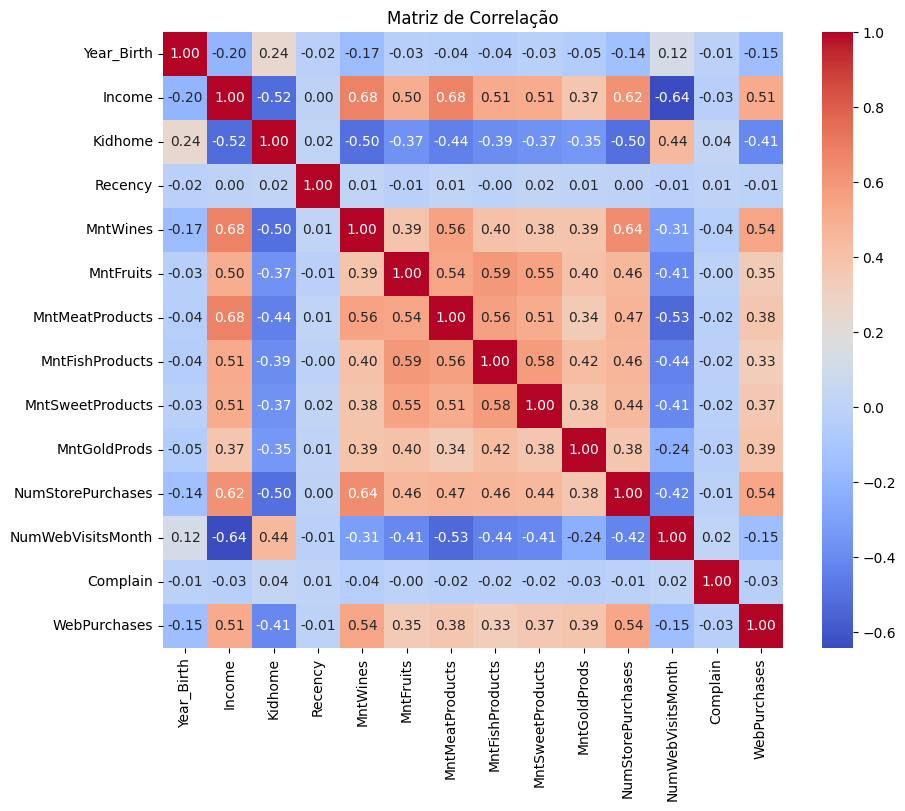

In [112]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Os tons mais próximos do branco indicam valores perto de zero, o que significa baixa correlação. Afim de investigar se há algum campo que não se relaciona com as outras variáveis, o mapa de cor foi reduzido aos valores entre - 0,1 e 0,1, intervalo aberto. Na prática, são valores significativos apenas na segunda casa decimal, ou seja, para o nosso caso, são valores considerados negligenciáveis.

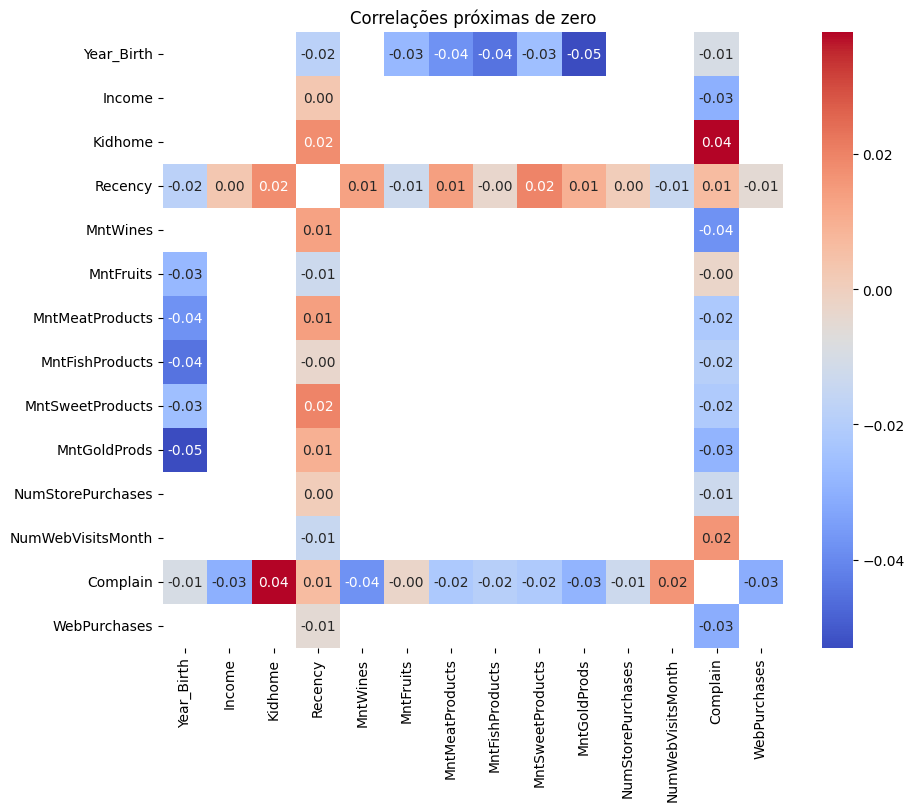

In [113]:
correlation_matrix_zero = correlation_matrix[(correlation_matrix<0.1)&(correlation_matrix>-0.1)]
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_zero, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlações próximas de zero')
plt.show()


É possível notar que os campos Recency e Complain não apresenm correlação razoável com nenhuma variável. Por esse motivo, optou-se por eliminá-las da base.

In [114]:
df.drop('Recency', axis =1, inplace=True)
df.drop('Complain', axis = 1, inplace=True)

In [115]:
print(f'Os campos restantes são:\n{df.columns}')

Os campos restantes são:
Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases',
       'NumWebVisitsMonth', 'WebPurchases'],
      dtype='object')


Voltando a análise da matriz de correlação, o próximo passo é focar a análise apenas na variável alvo, WebPurchase. Segue a lista apenas com as correlações da variável target com as variáveis features.

In [116]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix['WebPurchases'].sort_values()


Kidhome             -0.409932
Year_Birth          -0.152222
NumWebVisitsMonth   -0.149597
MntFishProducts      0.330342
MntFruits            0.345358
MntSweetProducts     0.366299
MntMeatProducts      0.377397
MntGoldProds         0.388735
Income               0.514426
NumStorePurchases    0.537666
MntWines             0.543195
WebPurchases         1.000000
Name: WebPurchases, dtype: float64

Os valores com maior correlação, da ordem de 0.5, são:
- Renda (Income)
- Número de compras na loja física (NumStorePurchases)
- Valor gasto em vinhos nos últimos 2 anos(MntWines)

Na sequência o números de crianças (Kidhome) destaca-se por uma relação inversamente proporcional, ou seja, quanto menor o número de crianças, mais compras online são feitas. Seguido das demais variáveis que indicam a quantidade gasta em outros produtos.

As variáveis com a menor correlação são número de visitas no mês (NumWebVisistsMont) e ano de nascimento (Year_Birth). Além, é claro, dos dois campos excluídos: número de dias desde a última compra (Recency) e reclamações (Complain).

Esses resultados preliminares já indicam algumas caracterísitcas do público desta loja:
- Quanto maior a renda, maior o gasto em compras online.
- Clientes de lojas físicas também tendem a efetuar compras online.
- O vinho se mostra ser o principal produto da loja online, pela qual, possivelmente, é reconhecida por parte de seus clientes.
- Visitas no site não tem se convertido em compras, pelo contrário, quanto mais acessos um cliente fez, menor sua chance de comprar.
- O público alvo da loja não tem faixa etária definida, pelo menos não com um comportamento linear
- O período entre uma compra e outra (recency) não está relacionado com nenhuma outra variável - o que não significa que o público não está fidelizado.
- Reclamações não se convertem em prejuízo para marca, indica confiança do público na marca  

Para ampliar a análise do comportamento dos clientes quanto sua renda, segue a lista de corelação entre a variável e as demais: 

In [117]:
correlation_matrix['Income'].sort_values()

NumWebVisitsMonth   -0.641560
Kidhome             -0.515799
Year_Birth          -0.203756
MntGoldProds         0.373151
MntFruits            0.500270
MntSweetProducts     0.511234
MntFishProducts      0.514007
WebPurchases         0.514426
NumStorePurchases    0.618183
MntMeatProducts      0.676678
MntWines             0.677335
Income               1.000000
Name: Income, dtype: float64

Há uma relação inversamente proporcional entre a renda (Income) e o número de visita ao site (NumWebVisitsMonth), e proporcional em relação ao número de compras em lojas física (NumStorePurchases) e virtual (WebPurchases ). Essa relação pode indicar que os clientes de alta rende são clientes fidelizados, que não são atraídos por click baits e promoções online, já que não frequentam o site, o acessam apenas para realizar as compras, e porque também compram em lojas físicas.

O vinho continua se mostrando o principal produto da loja, especialmente para aqueles de alta renda. O consumo dos outros produtos também cresce com a rende, e nenhum apresenta comportamento inversamente proporcional. Isso indica que não há um produto voltado para um nicho de renda, o consumo parece ser linear (quanto maior a renda, maiores as compras).

Destaca-se também o comportamento em inversamente proporcional ao número de crianças em casa. Essa variável pode ser mais explorada ao ser relacionada com o estado civil (marital status), analisada mais para frente.



Ainda no tema da renda e compra online, com a finalidade de entender se o comportamento dos clientes online são muito diferentes dos de compra em lija física, segue a comparação entre a correlação das duas variáveis.

Os comportamentos são similares, ainda que levemente diferentes. A maior diferença está no número de visitas ao site, pois aqueles que fazem compra em lojas físicas, como esperado, visitam menos o site do que aqueles que fazem compras online.

In [118]:
correlation_matrix[['NumStorePurchases', 'WebPurchases']]

,NumStorePurchases,WebPurchases
Year_Birth,-0.140653,-0.152222
Income,0.618183,0.514426
Kidhome,-0.501598,-0.409932
MntWines,0.638111,0.543195
MntFruits,0.457066,0.345358
MntMeatProducts,0.469090,0.377397
MntFishProducts,0.463741,0.330342
MntSweetProducts,0.443896,0.366299
MntGoldProds,0.375565,0.388735
NumStorePurchases,1.000000,0.537666


Em números absolutos para cada categoria, os nichos que mais rendem são de públicos em casal (Together e Married). Contudo, é fácil ver que se forem comparadas as somas das categorias de casal (Together e Married), com as categorias de solteiros (Widow, Single e Divorced), os solteiros representam uma parcela maior do faturamento.

O alto valor médio de compras online de viúvos (Widow) e divorciados (Divorced), indicam um público que pode ser mais explorado para aumentar as vendas, já que as categorias de casais já representam uma grande parte das vendas e podem estar saturadas, ou perto da saturação de vendas.

Já em relação ao nível de educação, clientes com graduação concentro o maior volume de venda, mas são clientes com PhD que tem maior média de compra individual. Isso significa que cada cliente com PhD tende a gastar mais do que um clietne com gradução. Assim, conquistar **um** cliente com PhD tende a se converter em maior faturamento do que conquistar **um** cliente com graduação. De maneira similar ao discutido anterior, esse público, junto daqueles com Mestrado/2n Cycle, são um público interessante de serem explorados.

In [119]:
x = 'WebPurchases' # quantitativo
y = 'Marital_Status' # categorico
z = 'Education' # categorico

agrupado_media = df.groupby(y)[x].mean().reset_index()
agrupado_soma = df.groupby(y)[x].sum().reset_index()

fig = make_subplots(rows=2, cols=2, subplot_titles=(f'Média das vendas por {y}',
                                                    f'Absoluto de vendas por {y}',
                                                    f'Média das vendas por {z}',
                                                    f'Absoluto de vendas por {z}',
                                                    ))

fig.add_trace(go.Bar(x=agrupado_media[x], y=agrupado_media[y],
                     orientation='h', marker=dict(color=agrupado_soma[x])),
                     row=1, col=1)

fig.add_trace(go.Bar(x=agrupado_soma[x], y=agrupado_soma[y],
                     orientation='h', marker=dict(color=agrupado_soma[x])),
                     row=1, col=2)

agrupado_media = df.groupby(z)[x].mean().reset_index()
agrupado_soma = df.groupby(z)[x].sum().reset_index()

fig.add_trace(go.Bar(x=agrupado_media[x], y=agrupado_media[z],
                     orientation='h', marker=dict(color=agrupado_soma[x])), 
                    row=2, col=1)

fig.add_trace(go.Bar(x=agrupado_soma[x], y=agrupado_soma[z], 
                     orientation='h', marker=dict(color=agrupado_soma[x])),
                     row=2, col=2)
fig.update_legends()
fig.update_layout(height=700, width=1200, showlegend=False)
fig.show()

No gráfico anterior vimos, por um lado, um comportamento parecido entre as classes Widow, Divorced e Phd.O mapa de árvore abaixo indica que há uma relação proporcional entre essas classes, um nicho de pessoas com formação PhD e viúvos e divordos. Por outro lado, apesar do comportamento parecido entre Married e Graduation, a maior dos casados tem PhD, não graduação. Isso pode indicar que o fator principal que leva ao consumo está mais relacionado com maior nível de educação, o que também pode indicar maior renda, do que com o status em si. Ainda assim, mantenho a sugestão de explorar o nicho de clientes divorciados e viúvos.  

In [120]:
# TreeMap

agrupado = df.groupby([y, z])[x].mean().reset_index()


fig = px.treemap(agrupado,
                 path=[y, z],
                 values=x,
                 title=f'{x} por {y} e {z}',
                 color=x)

fig.show()

A distribuição de vendas por idade, graficada abaixo, mostra que não nichos de idade bem delimitados, uma distribuição quase normal quase contínua com pico nas pessoas nascidas na década de 70 (entre 56 e 66 anos). Esse resultado está de acordo com os dois anteriores, já que essa idade é coerente com um nível superior maior, maior renda, e estatos de divórcio e casamento. Justamente em razão das categorias de cliente discutidas anteriormente, identifico que o público está mais relacionado a um estilo de vida, do que a uma idade específica.

In [121]:

cat2 = 'Year_Birth'
num = 'WebPurchases'

agrupado = df.groupby(cat2)[num].count().reset_index(name='abs')
agrupado['perc'] = 100 * agrupado['abs'] / agrupado['abs'].sum()

fig = px.histogram(agrupado, x=cat2, y='perc', barmode='overlay',
                   labels={'perc': 'Percentual (%)', cat2: cat2},
                   title='Distribuição Percentual', nbins=35)
fig.show()

Quanto ao produto mais vendido, vinho (MntWines), a análise da distribuição de vendas por renda mostra uma relação proporcional entre renda e compras de vinhos, mas não uma regra, pois quanto maior renda não necessariamente maior as compras. Esse resultado reforça a tese de que o público da loja está mais relacionado a um estilo de vida, que está intimamente ligada uma renda alta, do que apenas com uma categoria. O público da loja não pode ser categorizado segundo apenas um critério, suas múltiplas características devem ser levadas em conta. É sim, portanto, uma espécia de nicho formado por múltiplas categorias. 

In [123]:
x = df['Income']
y = df['MntWines']
fig = px.scatter(df, x=x, y=y, title='Dispersão entre x e y')
fig.show()


## Trainamento do Modelo

### Balanceamento

Como mostra o gráfico abaixo, a variável alvo está bem equilibrada, dispensando a necessidade um balanceamaneto.

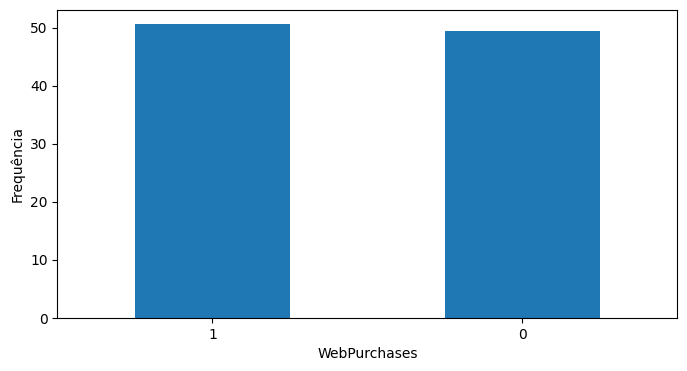

In [126]:
alvo = 'WebPurchases'
contagem_alvo = df[alvo].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo)
ax.set_ylabel('Frequência')
plt.xticks(rotation=0)

plt.show()

### **Codificação de Variáveis Categóricas:**

Nesta etapa, as variáveis categóricas serão transformadas em numéricas, para que os modelos de machine learning possam interpretar. Ambas as variáveis categóricas desta base, Marital_Status e Education, possuem mais de uma categoria. Por esse motivo, a técnica mais adequada é a Label Encoder, pois ela atribui um número único a cada valor da coluna. Em relação a técnica One Hot Enconding, essa técnica economiza memória.

Os resultados a seguir demonstram que a operação foi bem sucedida.
Para efetuar a transformação reversa, deve-se usar o método `inverse_transform()`, para obter a relação entre os números e as categorias, deve-se acessar a propriedade  `classes_`, como no exemplo.

In [127]:
label_encoder = LabelEncoder()
categorias = ['Marital_Status', 'Education']
for categoria in categorias:
    df[categoria] = label_encoder.fit_transform(df[categoria])

In [128]:
label_encoder.classes_

array(['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD'], dtype=object)

In [129]:
df[['Marital_Status', 'Education']].head(10)

,Marital_Status,Education
0,2,2
1,2,2
2,3,2
3,3,2
4,1,4
5,3,3
6,0,2
7,1,4
8,3,4
9,3,4


### **Separação das bases explicativa e alvo**

Separação das a base em Y, X usando o método de separação simples.

In [130]:
X = df.drop('WebPurchases', axis=1)  
y = df['WebPurchases']
print(f'Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:\nX: {X.shape[0]}\ny: {y.shape[0]}')

Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:
X: 2036
y: 2036


### Análise de Componentes Principais (PCA)

As componentes principais no PCA são combinações lineares das variáveis originais que formam bases ortoganais que descrevem a maior parte das variáveis explicativas. Tem como objetivo diminuir a complexidade dos dados.

O gráfico de variância explicada acumulada por componente, a seguir, indica quanto do comportamento da base de dados pode ser explicada a cada novo componente que se adiciona. No gráfico abaixo, com quatro componentes é possível explicar quase a totalidade dos dados, com seis, 100% pode ser descrita.

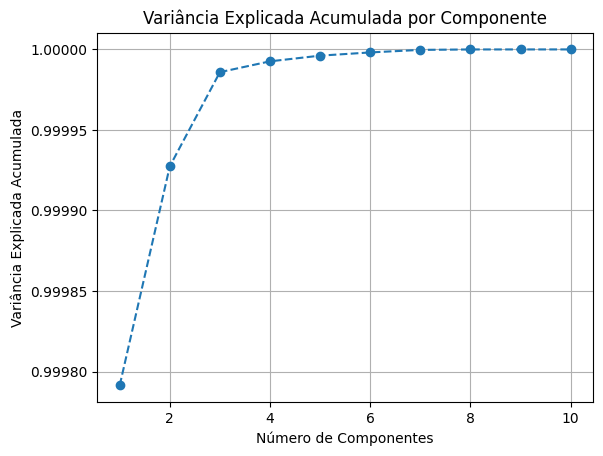

In [175]:
pca = PCA(n_components= 10 )
pca.fit(X)

# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_
# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando a variância explicada acumulada
plt.plot(range(1,11), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()


Cada componente indicado no eixo x é uma combinação linear das categorias da base. Assim, ao escolher descrever a base com 4 variáveis não estamos excluindo 9 variáveis e ficando apenas com 4. O que ocorre e que cada uma dessas componentes tem coeficientes que dão um peso de imporância para cada variável. Por exemplo, o vetor da primeira componente tem o seguinte formato:

In [184]:
print(pca.components_[0])

[-1.11046523e-04  7.75295274e-06  5.58333083e-07  9.99915991e-01
 -1.29065069e-05  1.05865556e-02  9.27352934e-04  7.17876373e-03
  1.30882316e-03  9.92310586e-04  9.03678762e-04  9.31325177e-05
 -7.28029657e-05]


Cada coeficiente desses múltiplica uma categoria de análise diferente da nossa base. Para aplicar o PCA não é necessário saber a relação entre esses coeficientes e suas categorias, mas é interessante analisar isso para fins de estudo.
Abaixo foi organizado um dataframe relacionando cada coeficiente a suas respectivas categorias. Repare a distribuição dos coeficientes para cada categoria da componente 1.

In [185]:
# Organiza os componentes principais em um DataFrame
componentes = pd.DataFrame(pca.components_, columns=X.columns)
print(componentes.loc[0].sort_values(ascending=False))

Income               9.999160e-01
MntWines             1.058656e-02
MntMeatProducts      7.178764e-03
MntFishProducts      1.308823e-03
MntSweetProducts     9.923106e-04
MntFruits            9.273529e-04
MntGoldProds         9.036788e-04
NumStorePurchases    9.313252e-05
Education            7.752953e-06
Marital_Status       5.583331e-07
Kidhome             -1.290651e-05
NumWebVisitsMonth   -7.280297e-05
Year_Birth          -1.110465e-04
Name: 0, dtype: float64


Note que as duas categorias com maior peso são as mesmas identificadas como mais relevantes durante a análise exploratória: renda (Income) e venda de vinhos (MntWines). Outros produtos aperecem como importantes na descrição da base, seguido das variáveis que também foram destacadas como relevantes anteriormente, tanto para contribuições proporcionais, com para as contribuições inversamente proporcionais. Explorar esses dados pode contribuir na análise de maneira similar, ainda que não substituitiva, que a análise dos coeficientes de correlação. Finalmente, é possível também analisar a soma de todos os coeficientes para cada categoria, como mostrado abaixo. O resultado é mais um indício coerente das análises e hipóteses levantadas anteriormente.

In [207]:
# Calcula o peso de cada campo com base nos coeficientes das componentes principais
peso_componentes = pd.DataFrame({
    'Peso': componentes.sum(axis=0)
}).sort_values(by='Peso', ascending=False)

print(peso_componentes)

                       Peso
MntFruits          1.409047
MntGoldProds       1.371006
NumStorePurchases  1.186978
MntMeatProducts    1.089339
Year_Birth         1.032164
Income             0.982528
NumWebVisitsMonth  0.789527
MntWines           0.715747
MntSweetProducts   0.336463
Kidhome            0.010729
Education         -0.049207
Marital_Status    -0.051125
MntFishProducts   -0.504606


Compreendido seu funcionamento, pdoe-se agora escolher quantas componentes serão escolhidas. Com o objetivo de simplificar ao máximo o modelo, optou-se por criar um modelo PCA com apenas quatro componentes. O gráfico abaixo mostra o resultado.

In [203]:
pca_4 = PCA(n_components= 4 )
pca_4.fit(X)
pca_4.feature_names_in_

array(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases',
       'NumWebVisitsMonth'], dtype=object)

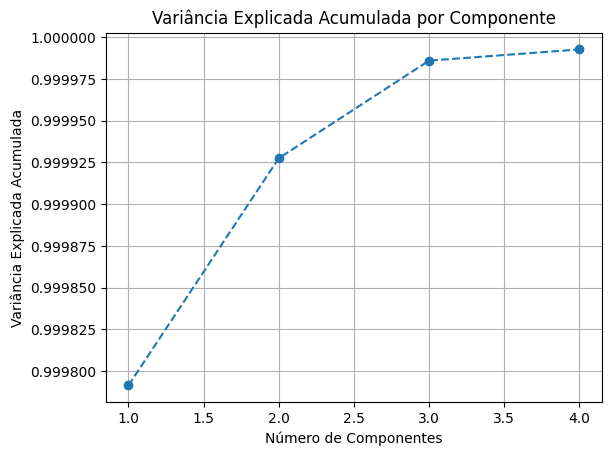

In [204]:
explained_variance = pca_4.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()
plt.plot(range(1, 5), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

In [ ]:
componentes_4 = pd.DataFrame(pca_4.components_, columns=X.columns)
peso_componentes_4 = pd.DataFrame({
    'Peso': componentes_4.sum(axis=0)
}).sort_values(by='Peso', ascending=False)
print(peso_componentes_4.sort_values(by='Peso', ascending=False))

                       Peso
MntMeatProducts    1.059354
Income             0.982241
MntWines           0.741823
MntFishProducts    0.725291
MntGoldProds       0.695341
MntSweetProducts   0.422071
MntFruits          0.417599
Year_Birth         0.018385
NumStorePurchases  0.014014
Marital_Status     0.000609
Kidhome           -0.002079
NumWebVisitsMonth -0.004596
Education         -0.005715


### **Separação das bases de treino e teste**

Separação das a base de treino e teste usando o método de separação simples.

In [133]:
X_pca = pca_4.fit_transform(X)

In [208]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.25, random_state=42)

In [209]:
print('Variáveis de teste:')
print(f'Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:\nX: {X_test.shape[0]}\ny: {y_test.shape[0]}\n')
print('Variáveis de treino:')
print(f'Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:\nX: {X_train.shape[0]}\ny: {y_train.shape[0]}')

Variáveis de teste:
Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:
X: 509
y: 509

Variáveis de treino:
Se os tamanhos das variáveis forem iguais, a separação foi bem sucedida:
X: 1527
y: 1527


### **Padronização das variáveis explicativas**

A padronização dos dados, especialmente das variáveis explicativas, é importante quando a técnica PCA for usada. O método aplicado foi o Standart Scaler, uma técnica que ajusta os dados para que tenham uma média de 0 e um desvio padrão de 1. Para evitar a 'contaminação' entre os daddos de teste e treino, elas foram transformadas separadamente, mas usando na de teste os mesmos parâmetros que na de treino.

In [210]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Aplica a mesma transformação (usando os parâmetros do treino) aos dados de teste
X_test_scaled = scaler.transform(X_test)

### **Modelagem: Regressão Logística**

Iniciar aplicando PCA depois alguma técnica para variaveis bináris

In [211]:
logistic = LogisticRegression(random_state = 42)
logistic.fit(X_train_scaled, y_train)
print(f"Intercept:\n{logistic.intercept_}")
print(f"Coeficientes:\n{logistic.coef_}")

Intercept:
[0.20568159]
Coeficientes:
[[ 1.48988647  0.91213293 -0.20734671  0.53115372]]


In [ ]:
previsoes_logic = logistic.predict(X_test_scaled)
relatorio_logic = classification_report(y_test, previsoes_logic)

*Análise do Gráfico da curva AUC-ROC*

Abaixo o Gráfico AUC_ROC mostra a curva ROC (Receiver Operating Characterisc), em laranja, e a curva em azul tracejada, que indica o limite de 50%. A curva ROC é a taxa de verdadeiros positivos (recall, ou sensibilidade) pela taxa de falsos positivos. Quanto maior a inclinação, maior a taxa de verdadeiros possitivos por falsos positivos, ou seja, melhor o modelo - até o limite de 1. Essa relação é calculada pela área embaixo da curva, AUC (Area Under  the Curve). A linha tracejada indica quando AUC é 50%, ou seja, quando a previsão passa a ter uma taxa de 50% de acerto.

Emoutras palavras, valores próximos de 1 indicam um bom modelo, enquanto valores próximos de 0.5 indicam um modelo aleatório.

Neste caso nosso modelo teve uma boa performance, com AUC  de 80%.


In [214]:
fpr, tpr, thresholds = roc_curve(y_test,previsoes_logic)

AUC: 0.80


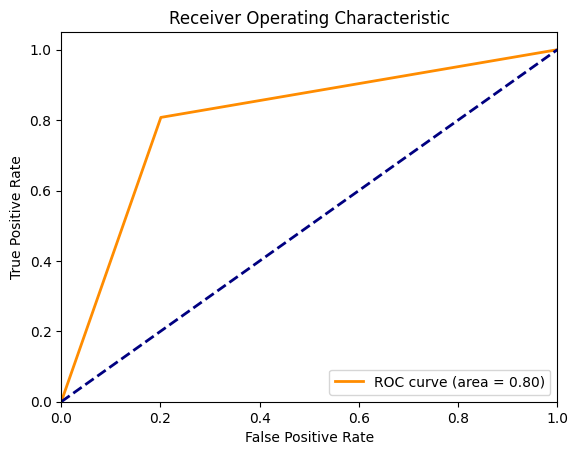

In [215]:
# Calcular a AUC
roc_auc = roc_auc_score(y_test, previsoes_logic)
print("AUC: {:.2f}".format(roc_auc))
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### **Modelagem: Random Forest**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

In [223]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
previsoes_rf = rf_model.predict(X_test_scaled)
relatorio_rf = classification_report(y_test, previsoes_rf)

### Avaliação da performance dos Modelos

A performance de cada modelo será avaliada conforme a matriz confusão e os parâmetros: precisão, sensibiidade, F1-score e acurácia.

A matriz confusão mostra uma tabela comparativa dos valores reais com as previsões. No eixo vertical estão os rótulos reais, enquanto no eixo horizontal estão os valores previstos pelo modelo. Assim, no segundo quadrante, tanto o rótulo real quanto o previsto são iguais a 0, caso em que o resultado é chamado de Verdadeiro-Negativo. De maneira similar, no quatro quadrante, ambos são iguais a 1, resultado esse chamado de Verdadeiro Positivo. Os resultados do primeiro e do terceiro quadrantes são, respectivamente, falso positivo e falso negativo. 

Já os parâmetros medem as seguintes características de cada modelo:
-  **Precisão** (Precision)
    - Mede a proporção de **previsões positivas corretas entre todas as previsões positivas** feitas pelo modelo. Ou seja, entre os exemplos que o modelo classificou como positivos, quantos eram realmente positivos. Alta precisão significa **poucos falsos positivos**.
- **Sensibilidade** (Revocação ou Recall)
    - Mede a proporção de **previsões positivas corretamente entre todas as previsões** pelo modelo, ou seja, entre todos os casos realmente positivos, quantos o modelo conseguiu encontrar. Alto recall significa **poucos falsos negativos**.
- **F1-score**
    - Média harmônica entre **precisão e recall**, oferecendo um equilíbrio entre ambos. É útil quando se quer um balanço entre os dois e em cenários com classes desbalanceadas.
- Acurácia (Accuracy)
    - **Proporção total de previsões corretas (positivas e negativas)** sobre o total de casos.


##### Seguem os resultados numéricos da avaliação

Relatório de Classificação da Regressão Logística:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       249
           1       0.81      0.81      0.81       260

    accuracy                           0.80       509
   macro avg       0.80      0.80      0.80       509
weighted avg       0.80      0.80      0.80       509

Matriz de Confusão da Regressão Logística:


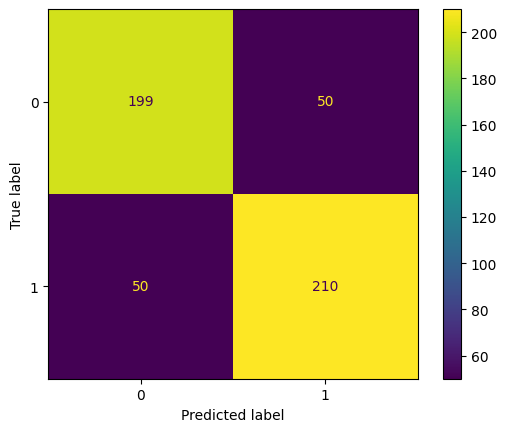

In [241]:
print("Relatório de Classificação da Regressão Logística:")
print(relatorio_logic)

print("Matriz de Confusão da Regressão Logística:")
print(ConfusionMatrixDisplay.from_predictions(y_test, previsoes_logic))


Relatório de Classificação da Random Florest:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       249
           1       0.81      0.91      0.86       260

    accuracy                           0.84       509
   macro avg       0.85      0.84      0.84       509
weighted avg       0.85      0.84      0.84       509


Matriz de Confusão da Random Forest:


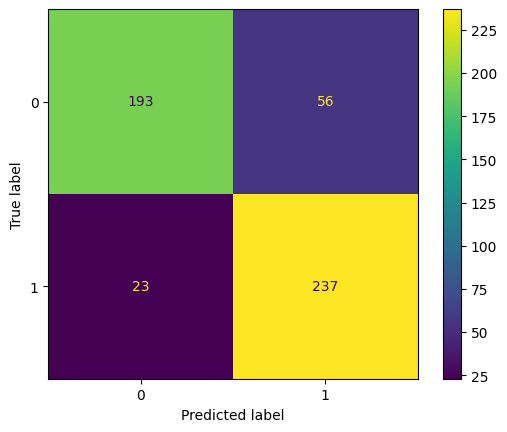

In [242]:
print("\nRelatório de Classificação da Random Florest:")
print(relatorio_rf)

print("\nMatriz de Confusão da Random Forest:")
print(ConfusionMatrixDisplay.from_predictions(y_test, previsoes_rf))

A principal diferença entre as matrizes de confusão são os valores de falsos negativos e verdadeiros positivos. O modelo random forest teve menos falsos negativos e mais verdadeiros positivos. Ou seja, ele errou menos ao indicar casos em que o cliente não ia comprar, mas na verdade comprou, e acertou mais vezes o caso em que o cliente iria comprar e de fato comprou. 

O que isso significa?
Significa que, em comparação ao modelo de regressão logística, o random forest tem maior capacidade em prever quando os clientes vão comprar e quando não vão. Esse resultado é confiramado pela comparação dos valores de recall para os casos positivos: 0.81 para a árvore de decisão e 0.91 para o random forest. É confirmado também por um melhor resultado médio, representado pelo F1-score, e absoluto, representado pela acurácia, do random forest em relação à árvore de decisão.